In [31]:
import torch
from rfdetr import RFDETRMedium
from PIL import Image
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import json

import math
import torch.nn.functional as F

In [32]:
model_path= "C:\\Users\\chris\\Downloads\\checkpoint_best_total.pth"
test_root = Path(r"C:\Users\chris\Documents\GitHub\DINO-LungDet\data\processed\test")
coco_path = test_root / "_annotations.coco.json"
model = RFDETRMedium(pretrain_weights=model_path,
    device="cuda"
)



[2026-03-16 18:41:28] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-16 18:41:28] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-16 18:41:29] [INFO] rf-detr - Loading pretrain weights


[2026-03-16 18:41:29] [WARNING] rf-detr - Reinitializing detection head with 1 classes based on pretrained weights, configured for 90.


In [33]:
with open(coco_path, "r", encoding="utf-8") as f:
    coco_data = json.load(f)

images_by_id = {img["id"]: img for img in coco_data["images"]}
anns_by_image_id = defaultdict(list)

for ann in coco_data["annotations"]:
    anns_by_image_id[ann["image_id"]].append(ann)

categories_by_id = {cat["id"]: cat for cat in coco_data.get("categories", [])}

print("num images      :", len(coco_data.get("images", [])))
print("num annotations :", len(coco_data.get("annotations", [])))
print("categories      :", categories_by_id)


num images      : 4393
num annotations : 4393
categories      : {0: {'id': 0, 'name': 'nodule', 'supercategory': 'common-objects'}}


In [34]:
core_model = model.model.model

print("\n--- named modules of core model ---")
for name, module in core_model.named_modules():
    print(name, type(module))


--- named modules of core model ---
 <class 'rfdetr.models.lwdetr.LWDETR'>
transformer <class 'rfdetr.models.transformer.Transformer'>
transformer.decoder <class 'rfdetr.models.transformer.TransformerDecoder'>
transformer.decoder.layers <class 'torch.nn.modules.container.ModuleList'>
transformer.decoder.layers.0 <class 'rfdetr.models.transformer.TransformerDecoderLayer'>
transformer.decoder.layers.0.self_attn <class 'torch.nn.modules.activation.MultiheadAttention'>
transformer.decoder.layers.0.self_attn.out_proj <class 'torch.nn.modules.linear.NonDynamicallyQuantizableLinear'>
transformer.decoder.layers.0.dropout1 <class 'torch.nn.modules.dropout.Dropout'>
transformer.decoder.layers.0.norm1 <class 'torch.nn.modules.normalization.LayerNorm'>
transformer.decoder.layers.0.cross_attn <class 'rfdetr.models.ops.modules.ms_deform_attn.MSDeformAttn'>
transformer.decoder.layers.0.cross_attn.sampling_offsets <class 'torch.nn.modules.linear.Linear'>
transformer.decoder.layers.0.cross_attn.attent

In [35]:
transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])



In [36]:
def load_image_as_tensor(image_path, transform, device):
    img_pil = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)   # [1, 3, 640, 640]
    return img_pil, img_tensor

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
core_model = core_model.to(device)
target_layer = core_model.transformer.decoder.layers[-1].cross_attn
core_model.eval()

LWDETR(
  (transformer): Transformer(
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (dropout1): Dropout(p=0, inplace=False)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (cross_attn): MSDeformAttn(
            (sampling_offsets): Linear(in_features=256, out_features=64, bias=True)
            (attention_weights): Linear(in_features=256, out_features=32, bias=True)
            (value_proj): Linear(in_features=256, out_features=256, bias=True)
            (output_proj): Linear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True

In [38]:
def coco_xywh_to_rel_cxcywh(coco_bbox, image_width, image_height):
    x, y, w, h = coco_bbox

    cx = x + w / 2.0
    cy = y + h / 2.0

    return [
        cx / image_width,
        cy / image_height,
        w / image_width,
        h / image_height,
    ]

In [39]:
def get_gt_boxes_for_image(image_id, images_by_id, anns_by_image_id, category_id=None):
    """
    returns:
        gt_boxes_rel: Liste von [cx, cy, w, h] relativ [0,1]
        gt_ann_list : originale Annotationen (optional nützlich fürs Debugging)
    """
    img_info = images_by_id[image_id]
    W = img_info["width"]
    H = img_info["height"]

    anns = anns_by_image_id.get(image_id, [])

    if category_id is not None:
        anns = [ann for ann in anns if ann["category_id"] == category_id]

    gt_boxes_rel = [
        coco_xywh_to_rel_cxcywh(ann["bbox"], W, H)
        for ann in anns
    ]

    return gt_boxes_rel, anns

# GradCAM

In [40]:
def select_target_query(pred_logits, target_class=0, strategy="top_score"):
    """
    pred_logits: [1, num_queries, num_classes]
    """
    probs = pred_logits[0].softmax(-1)  # [num_queries, num_classes]

    if strategy == "top_score":
        scores = probs[:, target_class]
        top_scores, top_idx = scores.sort(descending=True)
        target_query = top_idx[0].item()
        target_score = top_scores[0].item()
        return target_query, target_score

    raise ValueError(f"Unknown strategy: {strategy}")


In [41]:
def normalize_cam(cam, mode="signed", eps=1e-8):
    """
    cam: [H, W] tensor on cpu or gpu
    modes:
      - 'signed': divide by max abs -> range approx [-1, 1]
      - 'relu': ReLU + minmax -> range [0, 1]
      - 'minmax': plain minmax
      - 'abs': abs + minmax
    """
    cam = cam.detach()

    if mode == "signed":
        return cam / (cam.abs().max() + eps)

    elif mode == "relu":
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        return cam
    
    elif mode == "negative":
        cam = torch.relu(-cam)
        return cam / (cam.max() + eps)

    elif mode == "minmax":
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        return cam

    elif mode == "abs":
        cam = cam.abs()
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        return cam

    else:
        raise ValueError(f"Unknown normalization mode: {mode}")



In [42]:

def get_decoder_gradcam(
    core_model,
    img_tensor,
    target_layer,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="negative",
    box_weight=0.5
):
    """
    Decoder/Cross-Attention based Grad-CAM-like map.

    Returns dict with:
      - cam              : normalized cam [H, W]
      - raw_cam          : raw unnormalized cam [H, W]
      - target_query
      - target_class
      - target_score
      - target_logit
      - pred_logits
      - pred_boxes
    """
    saved = {}

    def forward_hook(module, inp, out):
        # inp[2] = flattened image features: [B, HW, C]
        saved["feat"] = inp[2]
        saved["feat"].retain_grad()

    handle = target_layer.register_forward_hook(forward_hook)

    core_model.zero_grad()
    outputs = core_model(img_tensor)

    pred_logits = outputs["pred_logits"]   # [1, 300, num_classes]
    pred_boxes  = outputs["pred_boxes"]

    if target_query is None:
        target_query, target_score = select_target_query(
            pred_logits,
            target_class=target_class,
            strategy=query_strategy,
        )
    else:
        probs = pred_logits[0].softmax(-1)
        target_score = probs[target_query, target_class].item()

    target_logit = pred_logits[0, target_query, target_class]
    target_box   = pred_boxes[0, target_query]
    target = target_logit + 0.5 * target_box.sum()
    target.backward()

    feat = saved["feat"]          # [1, HW, C]
    grad = saved["feat"].grad     # [1, HW, C]

    handle.remove()

    feat = feat[0]   # [HW, C]
    grad = grad[0]   # [HW, C]

    hw = feat.shape[0]
    side = int(hw ** 0.5)
    if side * side != hw:
        raise ValueError(f"Feature map is not square: HW={hw}")

    weights = grad.mean(dim=0)              # [C]
    cam_flat = (feat * weights).sum(dim=1)  # [HW]
    raw_cam = cam_flat.reshape(side, side)

    cam = normalize_cam(raw_cam, mode=cam_mode)

    return {
        "cam": cam.detach().cpu(),
        "raw_cam": raw_cam.detach().cpu(),
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_score,
        "target_logit": target_logit.item(),
        "target_box": target_box.detach().cpu(),
        "target_value": target.item(),
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def show_gradcam_on_image(pil_img, cam, alpha=0.4, cmap="jet", title="Grad-CAM"):
    """
    pil_img: PIL image (Originalbild)
    cam: torch tensor [H, W] oder numpy array
    """
    if torch.is_tensor(cam):
        cam = cam.detach().cpu()

    if not isinstance(cam, np.ndarray):
        cam = cam.numpy()

    cam_t = torch.tensor(cam, dtype=torch.float32)

    # auf Originalbildgröße bringen
    cam_resized = F.interpolate(
        cam_t.unsqueeze(0).unsqueeze(0),
        size=(pil_img.size[1], pil_img.size[0]),  # (H, W)
        mode="bilinear",
        align_corners=False
    )[0, 0].numpy()

    img_np = np.array(pil_img).astype(np.float32) / 255.0

    plt.figure(figsize=(8, 8))
    plt.imshow(img_np)
    plt.imshow(cam_resized, cmap=cmap, alpha=alpha)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [44]:
img_path = "A0007_1.3.6.1.4.1.14519.5.2.1.6655.2359.118972525676913596910705207496_16bit.png"   # <-- anpassen
img_pil,img_tensor=load_image_as_tensor(img_path, transform, device)


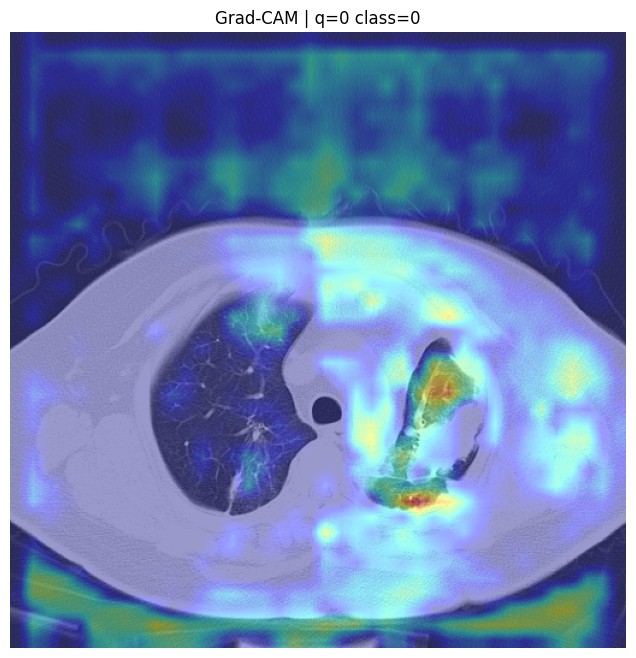

In [45]:
result = get_decoder_gradcam(
    core_model,
    img_tensor,
    target_layer=core_model.transformer.decoder.layers[-1].cross_attn,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="negative",   # oder "relu", "signed"
)

show_gradcam_on_image(
    img_pil,
    result["cam"],
    alpha=0.4,
    cmap="jet",
    title=f"Grad-CAM | q={result['target_query']} class={result['target_class']}")

In [67]:
# target_layer = core_model.transformer.decoder.layers[2].cross_attn

# result = get_decoder_gradcam(
#     core_model=core_model,
#     img_tensor=img_tensor,
#     target_layer=target_layer,
#     target_class=0,
#     target_query=None,          # automatisch beste Query nehmen
#     query_strategy="top_score",
#     cam_mode="signed",          # oder "relu"
# )

# cam = result["cam"]
# raw_cam = result["raw_cam"]

# print("target_query:", result["target_query"])
# print("target_score:", result["target_score"])
# print("target_logit:", result["target_logit"])
# print("cam shape:", cam.shape)
# print("raw cam min/max:", raw_cam.min().item(), raw_cam.max().item())
# print("cam min/max:", cam.min().item(), cam.max().item())

In [68]:
# import matplotlib.pyplot as plt
# import torch
# import torch.nn.functional as F
# import numpy as np
# from PIL import Image

# def show_gradcam_on_image(pil_img, cam, alpha=0.45, figsize=(8, 8)):
#     """
#     pil_img : PIL.Image
#     cam     : torch.Tensor oder np.array mit Shape [H, W]
#               idealerweise bereits auf 0..1 normalisiert
#     """

#     if isinstance(cam, torch.Tensor):
#         cam = cam.detach().cpu().numpy()

#     cam = np.asarray(cam, dtype=np.float32)

#     # Bild zu numpy [H, W, 3] in 0..1
#     img_np = np.array(pil_img).astype(np.float32) / 255.0

#     # CAM auf Bildgröße bringen
#     cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)  # [1,1,h,w]
#     cam_up = F.interpolate(
#         cam_t,
#         size=(img_np.shape[0], img_np.shape[1]),
#         mode="bilinear",
#         align_corners=False
#     )[0, 0].numpy()

#     # sicherheitshalber normalisieren
#     cam_up = cam_up - cam_up.min()
#     cam_up = cam_up / (cam_up.max() + 1e-8)

#     plt.figure(figsize=figsize)

#     plt.subplot(1, 3, 1)
#     plt.imshow(img_np)
#     plt.title("Original")
#     plt.axis("off")

#     plt.subplot(1, 3, 2)
#     plt.imshow(cam_up, cmap="jet")
#     plt.title("Grad-CAM")
#     plt.axis("off")

#     plt.subplot(1, 3, 3)
#     plt.imshow(img_np)
#     plt.imshow(cam_up, cmap="jet", alpha=alpha)
#     plt.title("Overlay")
#     plt.axis("off")

#     plt.tight_layout()
#     plt.show()

In [69]:
# cam = result["cam"]
# show_gradcam_on_image(image, cam)

# Attention Rollout

In [70]:
import types
import torch


def patch_decoder_self_attn_to_store_weights(core_model):
    patched = []

    for layer in core_model.transformer.decoder.layers:
        mha = layer.self_attn
        orig_forward = mha.forward

        def wrapped_forward(self, *args, _orig_forward=orig_forward, **kwargs):
            kwargs = dict(kwargs)
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = False

            out = _orig_forward(*args, **kwargs)

            if isinstance(out, tuple) and len(out) >= 2:
                attn_output, attn_weights = out[0], out[1]
                self._last_attn_weights = attn_weights
                return attn_output, attn_weights

            self._last_attn_weights = None
            return out

        mha._orig_forward_for_rollout = orig_forward
        mha.forward = types.MethodType(wrapped_forward, mha)
        mha._last_attn_weights = None
        patched.append(mha)

    def restore_fn():
        for mha in patched:
            if hasattr(mha, "_orig_forward_for_rollout"):
                mha.forward = mha._orig_forward_for_rollout
                del mha._orig_forward_for_rollout
            if hasattr(mha, "_last_attn_weights"):
                del mha._last_attn_weights

    return restore_fn

In [ ]:
import types
import torch


def select_target_query(pred_logits, target_class=0, strategy="top_score"):
    """
    pred_logits: [1, num_queries, num_classes]
    """
    probs = pred_logits[0].softmax(-1)

    if strategy == "top_score":
        scores = probs[:, target_class]
        top_scores, top_idx = scores.sort(descending=True)
        target_query = top_idx[0].item()
        target_score = top_scores[0].item()
        return target_query, target_score

    raise ValueError(f"Unknown strategy: {strategy}")


def patch_decoder_self_attn_to_store_weights(core_model):
    patched = []

    for layer in core_model.transformer.decoder.layers:
        mha = layer.self_attn
        orig_forward = mha.forward

        def wrapped_forward(self, *args, _orig_forward=orig_forward, **kwargs):
            kwargs = dict(kwargs)
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = False

            out = _orig_forward(*args, **kwargs)

            if isinstance(out, tuple) and len(out) >= 2:
                attn_output, attn_weights = out[0], out[1]
                self._last_attn_weights = attn_weights
                return attn_output, attn_weights

            self._last_attn_weights = None
            return out

        mha._orig_forward_for_rollout = orig_forward
        mha.forward = types.MethodType(wrapped_forward, mha)
        mha._last_attn_weights = None
        patched.append(mha)

    def restore_fn():
        for mha in patched:
            if hasattr(mha, "_orig_forward_for_rollout"):
                mha.forward = mha._orig_forward_for_rollout
                del mha._orig_forward_for_rollout
            if hasattr(mha, "_last_attn_weights"):
                del mha._last_attn_weights

    return restore_fn


def _normalize_attn_with_residual(attn, add_residual=True, eps=1e-8):
    """
    attn: [Q, Q]
    """
    q = attn.shape[0]
    if add_residual:
        attn = attn + torch.eye(q, device=attn.device, dtype=attn.dtype)
    attn = attn / (attn.sum(dim=-1, keepdim=True) + eps)
    return attn


def get_decoder_self_attn_rollout(
    core_model,
    img_tensor,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    add_residual=True,
):
    """
    Macht NUR decoder self-attn rollout.

    Returns:
      {
        "target_query": int,
        "target_class": int,
        "target_score": float,
        "target_logit": float,
        "query_rollout": [Q],          # Einfluss anderer Queries auf target_query
        "rollout_matrix": [Q, Q],      # volle Query->Query Rolloutmatrix
        "self_attn_maps": list[[Q,Q]], # pro Decoderlayer head-gemittelte self-attn
        "pred_logits": ...,
        "pred_boxes": ...,
      }
    """
    restore_fn = patch_decoder_self_attn_to_store_weights(core_model)

    try:
        core_model.zero_grad()
        outputs = core_model(img_tensor)

        pred_logits = outputs["pred_logits"]   # [1,Q,C]
        pred_boxes  = outputs["pred_boxes"]

        if target_query is None:
            target_query, target_score = select_target_query(
                pred_logits,
                target_class=target_class,
                strategy=query_strategy,
            )
            print(target_query)
        else:
            probs = pred_logits[0].softmax(-1)
            target_score = probs[target_query, target_class].item()

        target_logit = pred_logits[0, target_query, target_class]
        target_box   = pred_boxes[0, target_query]
        target = target_logit + 0.5 * target_box.sum()

        self_attn_maps = []
        for i, layer in enumerate(core_model.transformer.decoder.layers):
            w = getattr(layer.self_attn, "_last_attn_weights", None)
            if w is None:
                raise RuntimeError(f"Missing self-attn weights in decoder layer {i}")

            # w: [B, heads, Q, Q]
            w = w[0].mean(dim=0)  # [Q,Q], heads mitteln
            self_attn_maps.append(w.detach())

    finally:
        restore_fn()

    q = self_attn_maps[0].shape[0]
    rollout = torch.eye(q, device=self_attn_maps[0].device, dtype=self_attn_maps[0].dtype)

    for attn in self_attn_maps:
        a = _normalize_attn_with_residual(attn, add_residual=add_residual)
        rollout = a @ rollout

    query_rollout = rollout[target_query]
    query_rollout = query_rollout / (query_rollout.sum() + 1e-8)

    return {
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_score,
        "target_logit": target_logit.item(),
        "query_rollout": query_rollout.detach().cpu(),
        "rollout_matrix": rollout.detach().cpu(),
        "self_attn_maps": [x.detach().cpu() for x in self_attn_maps],
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }

In [72]:
import types
import torch
import torch.nn.functional as F


def select_target_query(pred_logits, target_class=0, strategy="top_score"):
    probs = pred_logits[0].softmax(-1)

    if strategy == "top_score":
        scores = probs[:, target_class]
        top_scores, top_idx = scores.sort(descending=True)
        target_query = top_idx[0].item()
        target_score = top_scores[0].item()
        return target_query, target_score

    raise ValueError(f"Unknown strategy: {strategy}")


def normalize_cam(cam, mode="signed", eps=1e-8):
    cam = cam.detach()

    if mode == "signed":
        return cam / (cam.abs().max() + eps)

    elif mode == "relu":
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        return cam

    elif mode == "minmax":
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        return cam

    elif mode == "abs":
        cam = cam.abs()
        cam = cam - cam.min()
        cam = cam / (cam.max() + eps)
        return cam

    else:
        raise ValueError(f"Unknown normalization mode: {mode}")


def patch_decoder_self_attn_to_store_weights(core_model):
    patched = []

    for layer in core_model.transformer.decoder.layers:
        mha = layer.self_attn
        orig_forward = mha.forward

        def wrapped_forward(self, *args, _orig_forward=orig_forward, **kwargs):
            kwargs = dict(kwargs)
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = False

            out = _orig_forward(*args, **kwargs)

            if isinstance(out, tuple) and len(out) >= 2:
                attn_output, attn_weights = out[0], out[1]
                self._last_attn_weights = attn_weights
                return attn_output, attn_weights

            self._last_attn_weights = None
            return out

        mha._orig_forward_for_rollout = orig_forward
        mha.forward = types.MethodType(wrapped_forward, mha)
        mha._last_attn_weights = None
        patched.append(mha)

    def restore_fn():
        for mha in patched:
            if hasattr(mha, "_orig_forward_for_rollout"):
                mha.forward = mha._orig_forward_for_rollout
                del mha._orig_forward_for_rollout
            if hasattr(mha, "_last_attn_weights"):
                del mha._last_attn_weights

    return restore_fn


def _normalize_attn_with_residual(attn, add_residual=True, eps=1e-8):
    q = attn.shape[0]
    if add_residual:
        attn = attn + torch.eye(q, device=attn.device, dtype=attn.dtype)
    attn = attn / (attn.sum(dim=-1, keepdim=True) + eps)
    return attn


def get_decoder_self_attn_rollout(
    core_model,
    img_tensor,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    add_residual=True,
):
    restore_fn = patch_decoder_self_attn_to_store_weights(core_model)

    try:
        core_model.zero_grad()
        outputs = core_model(img_tensor)

        pred_logits = outputs["pred_logits"]
        pred_boxes = outputs["pred_boxes"]

        if target_query is None:
            target_query, target_score = select_target_query(
                pred_logits,
                target_class=target_class,
                strategy=query_strategy,
            )
        else:
            probs = pred_logits[0].softmax(-1)
            target_score = probs[target_query, target_class].item()

        target_logit = pred_logits[0, target_query, target_class]

        self_attn_maps = []
        for i, layer in enumerate(core_model.transformer.decoder.layers):
            w = getattr(layer.self_attn, "_last_attn_weights", None)
            if w is None:
                raise RuntimeError(f"Missing self-attn weights in decoder layer {i}")

            # [B, heads, Q, Q] -> [Q, Q]
            w = w[0].mean(dim=0)
            self_attn_maps.append(w.detach())

    finally:
        restore_fn()

    q = self_attn_maps[0].shape[0]
    rollout = torch.eye(q, device=self_attn_maps[0].device, dtype=self_attn_maps[0].dtype)

    for attn in self_attn_maps:
        a = _normalize_attn_with_residual(attn, add_residual=add_residual)
        rollout = a @ rollout

    query_rollout = rollout[target_query]
    query_rollout = query_rollout / (query_rollout.sum() + 1e-8)

    return {
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_score,
        "target_logit": target_logit.item(),
        "query_rollout": query_rollout.detach().cpu(),
        "rollout_matrix": rollout.detach().cpu(),
        "self_attn_maps": [x.detach().cpu() for x in self_attn_maps],
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }


def _infer_num_heads_num_points(module, num_levels):
    num_heads = getattr(module, "n_heads", None)
    if num_heads is None:
        num_heads = getattr(module, "num_heads", None)
    if num_heads is None:
        num_heads = getattr(module, "n_head", None)

    num_points = getattr(module, "n_points", None)
    if num_points is None:
        num_points = getattr(module, "num_points", None)

    if num_heads is not None and num_points is not None:
        return int(num_heads), int(num_points)

    out_dim_offsets = module.sampling_offsets.out_features
    out_dim_weights = module.attention_weights.out_features

    # out_dim_offsets = heads * levels * points * 2
    # out_dim_weights = heads * levels * points
    found = []
    for h in [1, 2, 4, 8, 16, 32]:
        if out_dim_weights % (h * num_levels) == 0:
            p = out_dim_weights // (h * num_levels)
            if out_dim_offsets == h * num_levels * p * 2:
                found.append((h, p))

    if len(found) == 0:
        raise RuntimeError("Could not infer num_heads / num_points from MSDeformAttn module.")

    # meistens 8 heads
    return found[-1]


def _compute_sampling_locations(reference_points, sampling_offsets, num_points):
    """
    reference_points: [B,Q,L,4]
    sampling_offsets: [B,Q,H,L,P,2]
    returns:
      sampling_locations: [B,Q,H,L,P,2] in normalized coords
    """
    if reference_points.shape[-1] != 4:
        raise ValueError(f"Expected reference_points last dim = 4, got {reference_points.shape[-1]}")

    ref_xy = reference_points[..., :2][:, :, None, :, None, :]   # [B,Q,1,L,1,2]
    ref_wh = reference_points[..., 2:][:, :, None, :, None, :]   # [B,Q,1,L,1,2]

    sampling_locations = ref_xy + sampling_offsets / float(num_points) * ref_wh * 0.5
    return sampling_locations


def _splat_points_to_map(weights, locations, h, w):
    """
    weights:   [P]
    locations: [P,2] normalized x,y
    returns:
      map: [H,W]
    """
    device = weights.device
    dtype = weights.dtype

    out = torch.zeros((h, w), device=device, dtype=dtype)

    xs = locations[:, 0] * (w - 1)
    ys = locations[:, 1] * (h - 1)

    x0 = torch.floor(xs).long().clamp(0, w - 1)
    x1 = (x0 + 1).clamp(0, w - 1)
    y0 = torch.floor(ys).long().clamp(0, h - 1)
    y1 = (y0 + 1).clamp(0, h - 1)

    dx = xs - x0.float()
    dy = ys - y0.float()

    wa = (1 - dx) * (1 - dy)
    wb = dx * (1 - dy)
    wc = (1 - dx) * dy
    wd = dx * dy

    out.index_put_((y0, x0), weights * wa, accumulate=True)
    out.index_put_((y0, x1), weights * wb, accumulate=True)
    out.index_put_((y1, x0), weights * wc, accumulate=True)
    out.index_put_((y1, x1), weights * wd, accumulate=True)

    return out


def _project_msdeform_query_to_map(attn_w_q, samp_locs_q, spatial_shapes, out_h, out_w):
    """
    attn_w_q:    [heads, L, P]
    samp_locs_q: [heads, L, P, 2]
    spatial_shapes: [L,2] with (H_l, W_l)

    returns:
      dense map [out_h, out_w]
    """
    device = attn_w_q.device
    dtype = attn_w_q.dtype

    num_heads, num_levels, num_points = attn_w_q.shape
    dense = torch.zeros((out_h, out_w), device=device, dtype=dtype)

    for lvl in range(num_levels):
        h_l = int(spatial_shapes[lvl, 0].item())
        w_l = int(spatial_shapes[lvl, 1].item())

        lvl_map = torch.zeros((h_l, w_l), device=device, dtype=dtype)

        for head in range(num_heads):
            lvl_map += _splat_points_to_map(
                weights=attn_w_q[head, lvl],
                locations=samp_locs_q[head, lvl],
                h=h_l,
                w=w_l,
            )

        lvl_map_up = F.interpolate(
            lvl_map[None, None],
            size=(out_h, out_w),
            mode="bilinear",
            align_corners=False,
        )[0, 0]

        dense += lvl_map_up

    return dense


def get_decoder_self_cross_rollout_map(
    core_model,
    img_tensor,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="relu",
    add_self_attn_residual=True,
):
    """
    Kombiniert:
      - decoder self-attn rollout (Query -> Query)
      - decoder deformable cross-attn projection (Query -> Bild)

    Rückgabe:
      - rollout_map: [H_img, W_img]
      - raw_rollout_map: [H_img, W_img]
      - query_rollout: [Q]
      - per_query_map: [Q, H_img, W_img]
      - target_query, ...
    """
    device = img_tensor.device
    img_h, img_w = int(img_tensor.shape[-2]), int(img_tensor.shape[-1])

    # 1) self-attn rollout
    self_result = get_decoder_self_attn_rollout(
        core_model=core_model,
        img_tensor=img_tensor,
        target_class=target_class,
        target_query=target_query,
        query_strategy=query_strategy,
        add_residual=add_self_attn_residual,
    )

    target_query = self_result["target_query"]
    query_rollout = self_result["query_rollout"].to(device)   # [Q]

    # 2) cross-attn hook
    saved_cross = []
    handles = []

    def make_cross_hook(layer_idx):
        def cross_hook(module, inp, out):
            # laut deinem Debug:
            # inp[0] query             [B,Q,C]
            # inp[1] reference_points  [B,Q,L,4]
            # inp[2] value             [B,SumHW,C]
            # inp[3] spatial_shapes    [L,2]
            # inp[4] level_start_index [L]
            # inp[5] padding_mask      [B,SumHW]

            record = {"layer": layer_idx}

            query = inp[0]
            reference_points = inp[1]
            value = inp[2]
            spatial_shapes = inp[3]
            level_start_index = inp[4]
            padding_mask = inp[5] if len(inp) > 5 else None

            # falls spatial_shapes zufällig [1,2] ist, ist das schon [L,2]
            if spatial_shapes.dim() != 2 or spatial_shapes.shape[-1] != 2:
                raise RuntimeError(f"Unexpected spatial_shapes shape: {tuple(spatial_shapes.shape)}")

            b, q, c = query.shape
            num_levels = spatial_shapes.shape[0]

            num_heads, num_points = _infer_num_heads_num_points(module, num_levels)

            sampling_offsets = module.sampling_offsets(query)
            attention_weights = module.attention_weights(query)

            sampling_offsets = sampling_offsets.view(
                b, q, num_heads, num_levels, num_points, 2
            )

            attention_weights = attention_weights.view(
                b, q, num_heads, num_levels, num_points
            )
            attention_weights = F.softmax(attention_weights.view(b, q, num_heads, -1), dim=-1).view(
                b, q, num_heads, num_levels, num_points
            )

            sampling_locations = _compute_sampling_locations(
                reference_points=reference_points,
                sampling_offsets=sampling_offsets,
                num_points=num_points,
            )
            # print(f"\n[layer {layer_idx}]")
            # print("query.shape =", tuple(query.shape))
            # print("reference_points.shape =", tuple(reference_points.shape))
            # print("spatial_shapes =", spatial_shapes)
            # print("num_heads =", num_heads, "num_points =", num_points)

            # print("sampling_offsets min/max =",
            #     float(sampling_offsets.min()), float(sampling_offsets.max()))
            # print("attention_weights min/max =",
            #     float(attention_weights.min()), float(attention_weights.max()))
            # print("attention_weights sum first query/head =",
            #     float(attention_weights[0, 0, 0].sum()))

            # print("sampling_locations min/max =",
            #     float(sampling_locations.min()), float(sampling_locations.max()))

            # loc = sampling_locations[0, 0, 0, 0]  # first query, first head, first level -> [P,2]
            # print("first sampling locations =", loc[:min(8, loc.shape[0])])

            record["attention_weights"] = attention_weights.detach()
            record["sampling_locations"] = sampling_locations.detach()
            record["spatial_shapes"] = spatial_shapes.detach()
            saved_cross.append(record)

        return cross_hook

    try:
        for i, layer in enumerate(core_model.transformer.decoder.layers):
            handles.append(layer.cross_attn.register_forward_hook(make_cross_hook(i)))

        outputs = core_model(img_tensor)
        pred_logits = outputs["pred_logits"]
        pred_boxes = outputs["pred_boxes"]

    finally:
        for h in handles:
            h.remove()

    # 3) pro Query Bildkarten bauen
    q_total = pred_logits.shape[1]
    per_query_map = torch.zeros((q_total, img_h, img_w), device=device, dtype=img_tensor.dtype)

    saved_cross = sorted(saved_cross, key=lambda x: x["layer"])

    for rec in saved_cross:
        attn_w = rec["attention_weights"][0]       # [Q,H,L,P]
        samp_l = rec["sampling_locations"][0]      # [Q,H,L,P,2]
        spatial_shapes = rec["spatial_shapes"]     # [L,2]

        layer_maps = []
        for q_idx in range(q_total):
            q_map = _project_msdeform_query_to_map(
                attn_w_q=attn_w[q_idx],
                samp_locs_q=samp_l[q_idx],
                spatial_shapes=spatial_shapes,
                out_h=img_h,
                out_w=img_w,
            )
            layer_maps.append(q_map)

        layer_maps = torch.stack(layer_maps, dim=0)   # [Q,H,W]
        per_query_map += layer_maps

    per_query_map = per_query_map / max(len(saved_cross), 1)

    # 4) mit self-attn rollout über Queries aggregieren
    raw_rollout_map = (query_rollout[:, None, None] * per_query_map).sum(dim=0)
    rollout_map = normalize_cam(raw_rollout_map, mode=cam_mode)

    return {
        "rollout_map": rollout_map.detach().cpu(),
        "raw_rollout_map": raw_rollout_map.detach().cpu(),
        "query_rollout": query_rollout.detach().cpu(),
        "per_query_map": per_query_map.detach().cpu(),
        "target_query": target_query,
        "target_class": self_result["target_class"],
        "target_score": self_result["target_score"],
        "target_logit": self_result["target_logit"],
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }

In [73]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def _to_numpy_image(image):
    if torch.is_tensor(image):
        image = image.detach().cpu()
        if image.dim() == 3 and image.shape[0] in (1, 3):
            image = image.permute(1, 2, 0).numpy()
        else:
            image = image.numpy()

    image = np.asarray(image)

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)

    if image.dtype != np.float32 and image.dtype != np.float64:
        image = image.astype(np.float32)

    if image.max() > 1.0:
        image = image / 255.0

    image = np.clip(image, 0.0, 1.0)
    return image


def _to_numpy_heatmap(heatmap, out_h=None, out_w=None):
    if not torch.is_tensor(heatmap):
        heatmap = torch.tensor(np.asarray(heatmap), dtype=torch.float32)
    else:
        heatmap = heatmap.detach().cpu().float()

    if heatmap.dim() != 2:
        raise ValueError(f"heatmap must be [H,W], got {tuple(heatmap.shape)}")

    if out_h is not None and out_w is not None and tuple(heatmap.shape) != (out_h, out_w):
        heatmap = F.interpolate(
            heatmap[None, None],
            size=(out_h, out_w),
            mode="bilinear",
            align_corners=False,
        )[0, 0]

    heatmap = heatmap.numpy()
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap


def _cxcywh_to_xyxy(box, width, height):
    """
    box: [cx, cy, w, h]
    erwartet normalisierte DETR-Box in [0,1]
    """
    cx, cy, bw, bh = box
    x1 = (cx - bw / 2.0) * width
    y1 = (cy - bh / 2.0) * height
    x2 = (cx + bw / 2.0) * width
    y2 = (cy + bh / 2.0) * height
    return x1, y1, x2, y2


def overlay_heatmap_on_image_with_box(
    image,
    heatmap,
    pred_boxes=None,
    query_idx=None,
    box_format="cxcywh",
    alpha=0.45,
    cmap="jet",
    box_color="lime",
    box_linewidth=2.5,
    show_label=True,
    title=None,
    figsize=(8, 8),
):
    """
    image:
      - np.ndarray [H,W,3] oder torch.Tensor

    heatmap:
      - [H,W], wird auf Bildgröße resized

    pred_boxes:
      - Tensor/ndarray [Q,4] oder [1,Q,4]
      - typischerweise result["pred_boxes"]

    query_idx:
      - welche Query-Box gezeichnet werden soll

    box_format:
      - aktuell für RF-DETR/DETR meist "cxcywh" (normalisiert)
    """
    image = _to_numpy_image(image)
    img_h, img_w = image.shape[:2]

    heatmap = _to_numpy_heatmap(heatmap, out_h=img_h, out_w=img_w)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.imshow(heatmap, cmap=cmap, alpha=alpha)

    if pred_boxes is not None and query_idx is not None:
        if torch.is_tensor(pred_boxes):
            pred_boxes = pred_boxes.detach().cpu()
        pred_boxes = np.asarray(pred_boxes)

        if pred_boxes.ndim == 3:
            pred_boxes = pred_boxes[0]   # [Q,4]

        box = pred_boxes[query_idx]

        if box_format == "cxcywh":
            x1, y1, x2, y2 = _cxcywh_to_xyxy(box, img_w, img_h)
        else:
            raise ValueError(f"Unsupported box_format: {box_format}")

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=box_linewidth,
            edgecolor=box_color,
            facecolor="none",
        )
        ax.add_patch(rect)

        if show_label:
            ax.text(
                x1,
                max(0, y1 - 5),
                f"query {query_idx}",
                color=box_color,
                fontsize=11,
                bbox=dict(facecolor="black", alpha=0.5, pad=2, edgecolor="none"),
            )

    ax.axis("off")
    if title is not None:
        ax.set_title(title)
    plt.show()

# Pointing Game

In [74]:
import numpy as np


def normalize_signed_cam(cam, eps=1e-8):
    cam = cam.detach()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)
    return cam 

def is_point_in_box(point_xy, box_cxcywh, image_size):
    x, y = point_xy
    H, W = image_size

    cx, cy, bw, bh = box_cxcywh

    x1 = (cx - bw / 2.0) * W
    y1 = (cy - bh / 2.0) * H
    x2 = (cx + bw / 2.0) * W
    y2 = (cy + bh / 2.0) * H

    return (x1 <= x <= x2) and (y1 <= y <= y2)


def get_heatmap_max_point(heatmap, require_positive=True):
    heatmap = np.asarray(heatmap)

    if heatmap.ndim != 2:
        raise ValueError(f"heatmap must be 2D, got {heatmap.shape}")

    if heatmap.size == 0:
        return None, None

    if require_positive and np.max(heatmap) <= 0:
        return None, None

    flat_idx = np.argmax(heatmap)
    y, x = np.unravel_index(flat_idx, heatmap.shape)
    max_val = float(heatmap[y, x])

    return (int(x), int(y)), max_val


def get_pointing_game_result(heatmap, gt_boxes_rel, require_positive=True):
    if gt_boxes_rel is None or len(gt_boxes_rel) == 0:
        return {
            "valid": False,
            "hit": False,
            "max_point": None,
            "max_val": None,
            "hit_box_idx": -1,
            "reason": "no_gt_boxes",
        }

    max_point, max_val = get_heatmap_max_point(
        heatmap=heatmap,
        require_positive=require_positive
    )

    if max_point is None:
        return {
            "valid": False,
            "hit": False,
            "max_point": None,
            "max_val": None,
            "hit_box_idx": -1,
            "reason": "no_valid_heatmap_peak",
        }

    H, W = heatmap.shape

    for idx, box in enumerate(gt_boxes_rel):
        if is_point_in_box(max_point, box, image_size=(H, W)):
            return {
                "valid": True,
                "hit": True,
                "max_point": max_point,
                "max_val": max_val,
                "hit_box_idx": idx,
                "reason": "hit",
            }

    return {
        "valid": True,
        "hit": False,
        "max_point": max_point,
        "max_val": max_val,
        "hit_box_idx": -1,
        "reason": "miss",
    }


def summarize_pointing_game(results):
    valid_results = [r for r in results if r["valid"]]
    num_valid = len(valid_results)
    num_hits = sum(int(r["hit"]) for r in valid_results)

    return {
        "num_total": len(results),
        "num_valid": num_valid,
        "num_hits": num_hits,
        "num_misses": num_valid - num_hits,
        "pointing_game_score": num_hits / num_valid if num_valid > 0 else None,
    }

In [75]:
# image_id = 1

# result = get_decoder_gradcam(
#     core_model=core_model,
#     img_tensor=img_tensor,
#     target_layer=target_layer,
#     target_class=0,
#     target_query=None,          # automatisch beste Query nehmen
#     query_strategy="top_score",
#     cam_mode="signed",          # oder "relu"
# )

# cams = result["cam"]
# cams = normalize_signed_cam(cams)

# gt_boxes_rel, gt_anns = get_gt_boxes_for_image(
#     image_id=image_id,
#     images_by_id=images_by_id,
#     anns_by_image_id=anns_by_image_id,
#     category_id=None
# )

# result = get_pointing_game_result(
#     heatmap=cams.numpy(),          # deine 2D CAM als numpy array
#     gt_boxes_rel=gt_boxes_rel,
#     require_positive=True
# )

# print(result)

In [76]:
# heatmap=cams.numpy()
# print("shape:", heatmap.shape)
# print("min:", heatmap.min())
# print("max:", heatmap.max())

# flat_idx = np.argmax(heatmap)
# y, x = np.unravel_index(flat_idx, heatmap.shape)

# print("peak x,y:", (x, y))
# print("peak value:", heatmap[y, x])

In [77]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# def plot_pointing_game_debug(cam_norm, gt_boxes_rel, title="Pointing Game Debug"):
#     H, W = cam_norm.shape

#     max_point, max_val = get_heatmap_max_point(cam_norm)

#     fig, ax = plt.subplots(1, 1, figsize=(6, 6))
#     ax.imshow(cam_norm, cmap="jet")
#     ax.set_title(f"{title}\npeak={max_point}, val={max_val:.4f}")

#     for box in gt_boxes_rel:
#         cx, cy, bw, bh = box
#         x1 = (cx - bw / 2.0) * W
#         y1 = (cy - bh / 2.0) * H
#         rect = patches.Rectangle(
#             (x1, y1),
#             bw * W,
#             bh * H,
#             linewidth=2,
#             edgecolor="lime",
#             facecolor="none",
#         )
#         ax.add_patch(rect)

#     if max_point is not None:
#         ax.scatter([max_point[0]], [max_point[1]], c="white", s=80, marker="x")

#     plt.show()

In [78]:
# plot_pointing_game_debug(
#     cam_norm=cams.numpy(),
#     gt_boxes_rel=gt_boxes_rel,
#     title="Normalized Signed Grad-CAM"
# )

In [79]:
def summarize_pointing_game(results):
    valid_results = [r for r in results if r["valid"]]
    num_valid = len(valid_results)
    num_hits = sum(int(r["hit"]) for r in valid_results)

    return {
        "num_total": len(results),
        "num_valid": num_valid,
        "num_hits": num_hits,
        "num_misses": num_valid - num_hits,
        "pointing_game_score": num_hits / num_valid if num_valid > 0 else None,
    }

# Test Loop

In [80]:
all_pg_gradcam = []
all_pg_rollout_direct = []


In [81]:
for idx, (image_id, img_info) in enumerate(images_by_id.items()):
    print(f"Processing image {idx+1}/{len(images_by_id)}: ID={image_id}")

    img_path = test_root / img_info["file_name"]
    image, img_tensor = load_image_as_tensor(img_path, transform, device)


    gt_boxes_rel, gt_anns = get_gt_boxes_for_image(
        image_id=image_id,
        images_by_id=images_by_id,
        anns_by_image_id=anns_by_image_id,
        category_id=None
    )
    # -----------------------------
    # Grad-CAM
    # -----------------------------
    print("  Running Grad-CAM...")
    gradcam_result = get_decoder_gradcam(
        core_model=core_model,
        img_tensor=img_tensor,
        target_layer=target_layer,
        target_class=0,
        target_query=None,
        query_strategy="top_score",
        cam_mode="signed",
    )

    cam = gradcam_result["cam"]
    cam_norm = normalize_signed_cam(cam)

    pg_result_gradcam = get_pointing_game_result(
        heatmap=cam_norm.numpy(),
        gt_boxes_rel=gt_boxes_rel,
        require_positive=True
    )
    pg_result_gradcam["method"] = "gradcam"
    pg_result_gradcam["image_id"] = image_id
    pg_result_gradcam["file_name"] = img_info["file_name"]
    pg_result_gradcam["num_gt_boxes"] = len(gt_boxes_rel)
    pg_result_gradcam["target_query"] = gradcam_result["target_query"]
    pg_result_gradcam["target_class"] = gradcam_result["target_class"]
    pg_result_gradcam["target_score"] = float(gradcam_result["target_score"])

    all_pg_gradcam.append(pg_result_gradcam)

        # -----------------------------
    # Attention rollout
    # -----------------------------
    print("  Running Attention Rollout...")
    rollout_result = get_decoder_self_cross_rollout_map(
        core_model=core_model,
        img_tensor=img_tensor,
        target_class=0,
        target_query=None,
        query_strategy="top_score",
        cam_mode="minmax",
        add_self_attn_residual=True,
        # layer_weights=[1, 2, 3],   # optional
    )

    target_query = rollout_result["target_query"]

    # A) direkte Query-Karte (empfohlen)
    direct_map = rollout_result["per_query_map"][target_query]
    direct_map_norm = direct_map - direct_map.min()
    direct_map_norm = direct_map_norm / (direct_map_norm.max() + 1e-8)

    pg_result_rollout_direct = get_pointing_game_result(
        heatmap=direct_map_norm.numpy(),
        gt_boxes_rel=gt_boxes_rel,
        require_positive=True
    )
    pg_result_rollout_direct["method"] = "attn_rollout_direct"
    pg_result_rollout_direct["image_id"] = image_id
    pg_result_rollout_direct["file_name"] = img_info["file_name"]
    pg_result_rollout_direct["num_gt_boxes"] = len(gt_boxes_rel)
    pg_result_rollout_direct["target_query"] = rollout_result["target_query"]
    pg_result_rollout_direct["target_class"] = rollout_result["target_class"]
    pg_result_rollout_direct["target_score"] = float(rollout_result["target_score"])

    all_pg_rollout_direct.append(pg_result_rollout_direct)

Processing image 1/4393: ID=1
  Running Grad-CAM...
  Running Attention Rollout...
Processing image 2/4393: ID=2
  Running Grad-CAM...
  Running Attention Rollout...
Processing image 3/4393: ID=3
  Running Grad-CAM...
  Running Attention Rollout...
Processing image 4/4393: ID=4
  Running Grad-CAM...
  Running Attention Rollout...
Processing image 5/4393: ID=5
  Running Grad-CAM...
  Running Attention Rollout...


KeyboardInterrupt: 

In [ ]:
print("Grad-CAM:", summarize_pointing_game(all_pg_gradcam))
print("Rollout direct:", summarize_pointing_game(all_pg_rollout_direct))




=== FINAL POINTING GAME SUMMARY ===
num_total: 4393
num_valid: 4393
num_hits: 2736
num_misses: 1657
pointing_game_score: 0.622809014340997


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def normalize_cam(cam, mode="negative", eps=1e-8):
    """
    cam: [H, W] tensor

    modes:
      - 'signed'   : normalize to approx [-1, 1]
      - 'relu'     : positive evidence only
      - 'negative' : negative evidence only
      - 'minmax'   : plain min-max
      - 'abs'      : absolute magnitude
    """
    cam = cam.detach()

    if mode == "signed":
        return cam / (cam.abs().max() + eps)

    if mode == "relu":
        cam = torch.relu(cam)
        return cam / (cam.max() + eps)

    if mode == "negative":
        cam = torch.relu(-cam)
        return cam / (cam.max() + eps)

    if mode == "minmax":
        cam = cam - cam.min()
        return cam / (cam.max() + eps)

    if mode == "abs":
        cam = cam.abs()
        return cam / (cam.max() + eps)

    raise ValueError(f"Unknown normalization mode: {mode}")


def select_target_query(pred_logits, target_class=0, strategy="top_score"):
    """
    pred_logits: [1, num_queries, num_classes]
    """
    probs = pred_logits[0].softmax(-1)

    if strategy == "top_score":
        scores = probs[:, target_class]
        q = scores.argmax().item()
        s = scores[q].item()
        return q, s

    raise ValueError(f"Unknown query strategy: {strategy}")


def box_cxcywh_to_xyxy_pixel(box, pil_img):
    """
    box: [cx, cy, w, h] normalized to [0,1]
    returns: [x0, y0, x1, y1] in pixel coordinates
    """
    w_img, h_img = pil_img.size
    cx, cy, w, h = box.tolist()

    x0 = (cx - w / 2) * w_img
    y0 = (cy - h / 2) * h_img
    x1 = (cx + w / 2) * w_img
    y1 = (cy + h / 2) * h_img

    return [x0, y0, x1, y1]


def resize_cam_to_image(cam, pil_img):
    """
    cam: [H, W] tensor or numpy array
    returns resized cam as numpy array
    """
    if torch.is_tensor(cam):
        cam_t = cam.detach().cpu().float()
    else:
        cam_t = torch.tensor(cam, dtype=torch.float32)

    cam_up = F.interpolate(
        cam_t.unsqueeze(0).unsqueeze(0),
        size=(pil_img.size[1], pil_img.size[0]),
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()

    return cam_up


def show_cam_on_image(
    pil_img,
    cam,
    title="Grad-CAM",
    cmap="jet",
    alpha=0.4,
    box_xyxy=None,
):
    """
    Display CAM overlay on original image.
    """
    img_np = np.array(pil_img).astype(np.float32) / 255.0
    cam_up = resize_cam_to_image(cam, pil_img)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img_np)
    ax.imshow(cam_up, cmap=cmap, alpha=alpha)

    if box_xyxy is not None:
        x0, y0, x1, y1 = box_xyxy
        rect = plt.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title(title)
    ax.axis("off")
    plt.show()

    return cam_up


def get_conv_gradcam(
    core_model,
    img_tensor,
    pil_img,
    target_layer=None,
    target_class=0,
    target_query=None,
    query_strategy="top_score",
    cam_mode="negative",
    use_box_term=False,
    box_weight=0.5,
    show=True,
    draw_box=False,
):
    """
    Conv-based Grad-CAM for RF-DETR backbone/projector layers.

    Returns dict with:
      - cam
      - raw_cam
      - cam_up
      - target_query
      - target_class
      - target_score
      - target_logit
      - target_box
      - target_value
      - pred_logits
      - pred_boxes
    """
    if target_layer is None:
        target_layer = core_model.backbone[0].projector.stages[0][0].cv2.conv

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_input, grad_output):
        gradients["value"] = grad_output[0]

    fwd_handle = target_layer.register_forward_hook(forward_hook)
    bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    core_model.zero_grad()
    outputs = core_model(img_tensor)

    pred_logits = outputs["pred_logits"]   # [1, 300, num_classes]
    pred_boxes = outputs["pred_boxes"]     # [1, 300, 4]

    if target_query is None:
        target_query, target_score = select_target_query(
            pred_logits,
            target_class=target_class,
            strategy=query_strategy,
        )
    else:
        probs = pred_logits[0].softmax(-1)
        target_score = probs[target_query, target_class].item()

    target_logit = pred_logits[0, target_query, target_class]
    target_box = pred_boxes[0, target_query]

    if use_box_term:
        target = target_logit + box_weight * target_box.sum()
    else:
        target = target_logit

    target.backward()

    act = activations["value"]   # [1, C, H, W]
    grad = gradients["value"]    # [1, C, H, W]

    fwd_handle.remove()
    bwd_handle.remove()

    weights = grad.mean(dim=(2, 3), keepdim=True)         # [1, C, 1, 1]
    raw_cam = (weights * act).sum(dim=1, keepdim=True)    # [1, 1, H, W]
    raw_cam_2d = raw_cam[0, 0].detach().cpu()

    cam = normalize_cam(raw_cam_2d, mode=cam_mode)

    cam_up = resize_cam_to_image(cam, pil_img)

    if show:
        cmap = "seismic" if cam_mode == "signed" else "jet"
        title_extra = "class+box" if use_box_term else "class-only"

        box_xyxy = None
        if draw_box:
            box_xyxy = box_cxcywh_to_xyxy_pixel(target_box.detach().cpu(), pil_img)

        show_cam_on_image(
            pil_img=pil_img,
            cam=cam,
            title=f"Conv Grad-CAM | q={target_query} c={target_class} | {cam_mode} | {title_extra}",
            cmap=cmap,
            alpha=0.4,
            box_xyxy=box_xyxy,
        )

    return {
        "cam": cam.detach().cpu(),
        "raw_cam": raw_cam_2d.detach().cpu(),
        "cam_up": cam_up,
        "target_query": target_query,
        "target_class": target_class,
        "target_score": target_score,
        "target_logit": target_logit.item(),
        "target_box": target_box.detach().cpu(),
        "target_value": target.item(),
        "pred_logits": pred_logits.detach().cpu(),
        "pred_boxes": pred_boxes.detach().cpu(),
    }




In [90]:
def load_image_as_tensor(image_path, transform, device):
    img_pil = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)   # [1, 3, 640, 640]
    return img_pil, img_tensor

pil_img, img_tensor=load_image_as_tensor("A0130_1.3.6.1.4.1.14519.5.2.1.6655.2359.188820884948930765338187197823_16bit.png",transform,device)

In [91]:
model_path= "C:\\Users\\chris\\Downloads\\checkpoint_best_total.pth"

In [92]:
model = RFDETRMedium(pretrain_weights=model_path,
    device="cuda"
)

[2026-03-16 20:03:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-16 20:03:44] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-16 20:03:44] [INFO] rf-detr - Loading pretrain weights


[2026-03-16 20:03:44] [WARNING] rf-detr - Reinitializing detection head with 1 classes based on pretrained weights, configured for 90.


In [93]:
print(type(model))
print(model)

<class 'rfdetr.detr.RFDETRMedium'>


In [94]:
core_model = model.model.model

print("\n--- named modules of core model ---")
for name, module in core_model.named_modules():
    print(name, type(module))


--- named modules of core model ---
 <class 'rfdetr.models.lwdetr.LWDETR'>
transformer <class 'rfdetr.models.transformer.Transformer'>
transformer.decoder <class 'rfdetr.models.transformer.TransformerDecoder'>
transformer.decoder.layers <class 'torch.nn.modules.container.ModuleList'>
transformer.decoder.layers.0 <class 'rfdetr.models.transformer.TransformerDecoderLayer'>
transformer.decoder.layers.0.self_attn <class 'torch.nn.modules.activation.MultiheadAttention'>
transformer.decoder.layers.0.self_attn.out_proj <class 'torch.nn.modules.linear.NonDynamicallyQuantizableLinear'>
transformer.decoder.layers.0.dropout1 <class 'torch.nn.modules.dropout.Dropout'>
transformer.decoder.layers.0.norm1 <class 'torch.nn.modules.normalization.LayerNorm'>
transformer.decoder.layers.0.cross_attn <class 'rfdetr.models.ops.modules.ms_deform_attn.MSDeformAttn'>
transformer.decoder.layers.0.cross_attn.sampling_offsets <class 'torch.nn.modules.linear.Linear'>
transformer.decoder.layers.0.cross_attn.attent

In [95]:
# from PIL import Image
# from torchvision import transforms


# img_path = "A0007_1.3.6.1.4.1.14519.5.2.1.6655.2359.118972525676913596910705207496_16bit.png"
# image = Image.open(img_path).convert("RGB")
# transform = transforms.Compose([
#     transforms.Resize((640, 640)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     ),
# ])

# img_tensor = transform(image).unsqueeze(0)
core_model = model.model.model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_tensor = img_tensor.to(device)
core_model = core_model.to(device)
core_model.eval()

print(img_tensor.shape)

torch.Size([1, 3, 640, 640])


In [96]:
for name, module in core_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print(name)

backbone.0.encoder.encoder.embeddings.patch_embeddings.projection
backbone.0.projector.stages.0.0.cv1.conv
backbone.0.projector.stages.0.0.cv2.conv
backbone.0.projector.stages.0.0.m.0.cv1.conv
backbone.0.projector.stages.0.0.m.0.cv2.conv
backbone.0.projector.stages.0.0.m.1.cv1.conv
backbone.0.projector.stages.0.0.m.1.cv2.conv
backbone.0.projector.stages.0.0.m.2.cv1.conv
backbone.0.projector.stages.0.0.m.2.cv2.conv


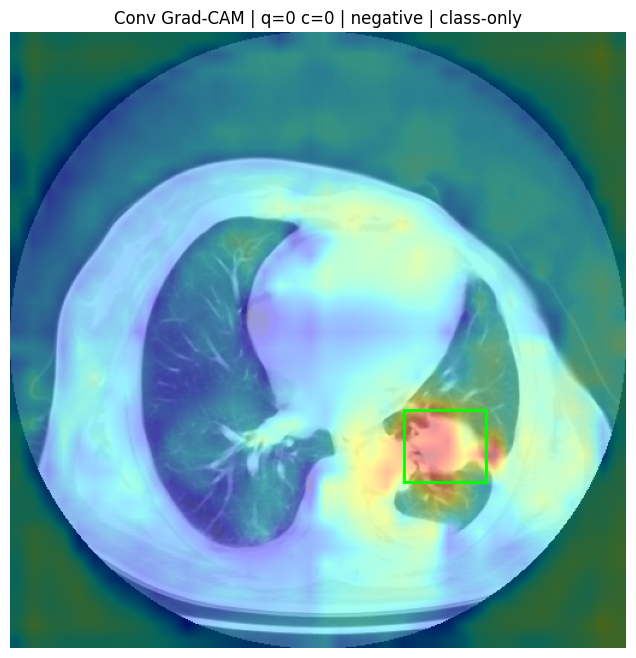

dict_keys(['cam', 'raw_cam', 'cam_up', 'target_query', 'target_class', 'target_score', 'target_logit', 'target_box', 'target_value', 'pred_logits', 'pred_boxes'])
query: 0
class: 0
score: 0.9996200799942017
logit: 1.2952666282653809


In [97]:
result = get_conv_gradcam(
    core_model=core_model,
    img_tensor=img_tensor,
    pil_img=pil_img,
    target_layer = core_model.backbone[0].projector.stages[0][0].cv2.conv,
    target_class=0,
    target_query=None,          # oder z.B. 0
    query_strategy="top_score",
    cam_mode="negative",        # "relu", "negative", "signed"
    use_box_term=False,         # True für class+box
    box_weight=0.5,
    show=True,
    draw_box=True,
)

print(result.keys())
print("query:", result["target_query"])
print("class:", result["target_class"])
print("score:", result["target_score"])
print("logit:", result["target_logit"])